# Results of patient 3

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

#### Loading the files

I encountered an error with the markers in session 14, which is why only sessions 3-13 are included in the online performance scores.
I am still trying to debug this issue.

In [57]:
with open('performances_p3_remaining_wo_s14_r10', 'rb') as f:
    performances_p3_remaining = pickle.load(f) 

print(performances_p3_remaining.keys())


dict_keys(['p3_s13_static', 'p3_s13_adaptive_sw', 'p3_s14_static', 'p3_s14_adaptive_sw', 'p3_s15_static', 'p3_s15_adaptive_sw', 'p3_s16_static', 'p3_s16_adaptive_sw'])


In [58]:
with open('performances_p3_incomplete_wo_s3.pkl', 'rb') as f:
    performances_p3_incomplete = pickle.load(f) 

with open('performances_p3_incomplete_2205.pkl', 'rb') as f:
    performances_p3_incomplete_2205 = pickle.load(f)     

print(performances_p3_incomplete.keys())
print(performances_p3_incomplete_2205.keys())    

dict_keys(['p3_s4_static', 'p3_s4_adaptive_sw', 'p3_s5_static', 'p3_s5_adaptive_sw', 'p3_s6_static', 'p3_s6_adaptive_sw', 'p3_s7_static', 'p3_s7_adaptive_sw', 'p3_s8_static', 'p3_s8_adaptive_sw', 'p3_s9_static', 'p3_s9_adaptive_sw', 'p3_s10_static', 'p3_s10_adaptive_sw', 'p3_s11_static', 'p3_s11_adaptive_sw', 'p3_s12_static', 'p3_s12_adaptive_sw', 'p3_s13_static', 'p3_s13_adaptive_sw'])
dict_keys(['p3_s3_static', 'p3_s3_adaptive_sw', 'p3_s4_static', 'p3_s4_adaptive_sw', 'p3_s5_static', 'p3_s5_adaptive_sw', 'p3_s6_static', 'p3_s6_adaptive_sw', 'p3_s7_static', 'p3_s7_adaptive_sw', 'p3_s8_static', 'p3_s8_adaptive_sw', 'p3_s9_static', 'p3_s9_adaptive_sw', 'p3_s10_static', 'p3_s10_adaptive_sw', 'p3_s11_static', 'p3_s11_adaptive_sw', 'p3_s12_static', 'p3_s12_adaptive_sw', 'p3_s13_static', 'p3_s13_adaptive_sw'])


In [69]:
combined_performances = dict()
combined_performances.update(performances_p3_incomplete_2205)
combined_performances.update(performances_p3_remaining)
print(combined_performances.keys())

dict_keys(['p3_s3_static', 'p3_s3_adaptive_sw', 'p3_s4_static', 'p3_s4_adaptive_sw', 'p3_s5_static', 'p3_s5_adaptive_sw', 'p3_s6_static', 'p3_s6_adaptive_sw', 'p3_s7_static', 'p3_s7_adaptive_sw', 'p3_s8_static', 'p3_s8_adaptive_sw', 'p3_s9_static', 'p3_s9_adaptive_sw', 'p3_s10_static', 'p3_s10_adaptive_sw', 'p3_s11_static', 'p3_s11_adaptive_sw', 'p3_s12_static', 'p3_s12_adaptive_sw', 'p3_s13_static', 'p3_s13_adaptive_sw', 'p3_s14_static', 'p3_s14_adaptive_sw', 'p3_s15_static', 'p3_s15_adaptive_sw', 'p3_s16_static', 'p3_s16_adaptive_sw'])


In [64]:
print(performances_p3_incomplete_2205.get('p3_s13_static'))
print(performances_p3_remaining.get('p3_s13_static').values())

{'epoch-wise': {'lda': 0.7495943216712242, 'slda': 0.7466723477321684, 'btlda': 0.7450877834324984}, 'trial-wise': {'lda': 0.8717948717948718, 'slda': 0.8782051282051282, 'btlda': 0.8782051282051282}, 'trial_predictions': {'lda': array([2., 6., 3., 5., 1., 4., 6., 2., 1., 3., 4., 5., 4., 4., 2., 6., 3.,
       1., 3., 1., 6., 4., 2., 6., 2., 3., 3., 1., 6., 2., 1., 4., 6., 1.,
       4., 3., 2., 2., 3., 6., 5., 1., 3., 1., 2., 4., 6., 2., 1., 6., 4.,
       2., 3., 6., 2., 6., 5., 3., 1., 4., 6., 6., 6., 1., 2., 3., 6., 3.,
       1., 5., 4., 2., 1., 5., 5., 3., 6., 4., 2., 1., 5., 6., 4., 3., 5.,
       3., 1., 4., 2., 6., 4., 6., 3., 6., 1., 2., 6., 2., 4., 1., 3., 6.,
       3., 4., 6., 2., 6., 1., 3., 5., 4., 1., 6., 2., 6., 2., 3., 2., 2.,
       1., 2., 1., 6., 4., 3., 5., 5., 3., 1., 3., 2., 4., 1., 2., 5., 6.,
       5., 3., 4., 3., 2., 6., 1., 6., 2., 6., 1., 3., 5., 4., 4., 3., 5.,
       2., 1., 6.]), 'slda': array([2., 6., 5., 5., 1., 4., 6., 2., 1., 3., 4., 5., 4., 3., 2.,

#### Extract performance scores

In [73]:
performances_p3_incomplete_2205 = combined_performances

### Epoch-wise accuracy
# static - trained on previous session
ews_static_lda = np.zeros(14) # 1 online sessions were stored (in session 14 I encountered an error)
ews_static_slda = np.zeros(14)
ews_static_btlda = np.zeros(14)
# adaptive - sliding window
ews_adaptive_sw_lda = np.zeros(14) 
ews_adaptive_sw_slda = np.zeros(14)
ews_adaptive_sw_btlda = np.zeros(14)

session = 3

for i in range(14):
    ews_static_lda[i] = performances_p3_incomplete_2205.get(f'p3_s{session}_static').get('epoch-wise').get('lda')
    ews_static_slda[i] = performances_p3_incomplete_2205.get(f'p3_s{session}_static').get('epoch-wise').get('slda')
    ews_static_btlda[i] = performances_p3_incomplete_2205.get(f'p3_s{session}_static').get('epoch-wise').get('btlda')

    ews_adaptive_sw_lda[i] = performances_p3_incomplete_2205.get(f'p3_s{session}_adaptive_sw').get('epoch-wise').get('lda')
    ews_adaptive_sw_slda[i] = performances_p3_incomplete_2205.get(f'p3_s{session}_adaptive_sw').get('epoch-wise').get('slda')
    ews_adaptive_sw_btlda[i] = performances_p3_incomplete_2205.get(f'p3_s{session}_adaptive_sw').get('epoch-wise').get('btlda')
    session+=1  

### Trial-wise accuracy
# static - trained on previous session
tws_static_lda = np.zeros(14) 
tws_static_slda = np.zeros(14)
tws_static_btlda = np.zeros(14)
# adaptive - sliding window
tws_adaptive_sw_lda = np.zeros(14) 
tws_adaptive_sw_slda = np.zeros(14)
tws_adaptive_sw_btlda = np.zeros(14)

session = 3

for i in range(14):
    tws_static_lda[i] = performances_p3_incomplete_2205.get(f'p3_s{session}_static').get('trial-wise').get('lda')
    tws_static_slda[i] = performances_p3_incomplete_2205.get(f'p3_s{session}_static').get('trial-wise').get('slda')
    tws_static_btlda[i] = performances_p3_incomplete_2205.get(f'p3_s{session}_static').get('trial-wise').get('btlda')

    tws_adaptive_sw_lda[i] = performances_p3_incomplete_2205.get(f'p3_s{session}_adaptive_sw').get('trial-wise').get('lda')
    tws_adaptive_sw_slda[i] = performances_p3_incomplete_2205.get(f'p3_s{session}_adaptive_sw').get('trial-wise').get('slda')
    tws_adaptive_sw_btlda[i] = performances_p3_incomplete_2205.get(f'p3_s{session}_adaptive_sw').get('trial-wise').get('btlda')
    session+=1

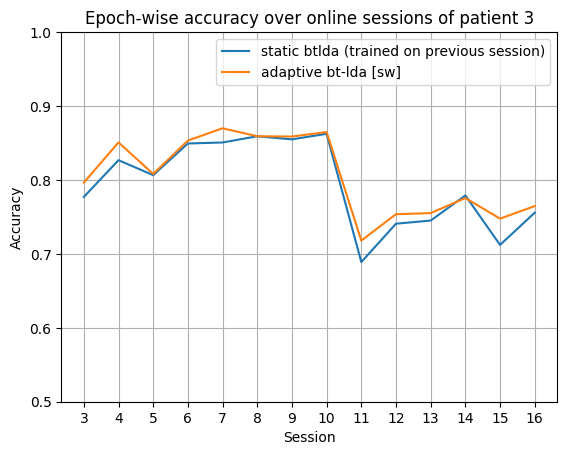

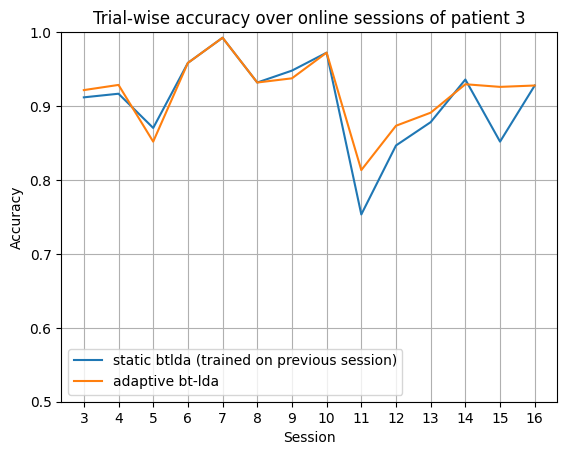

In [75]:
# Plot 1: Epoch-wise acc of static lda vs slda vs btlda

plt.figure()
#
#plt.plot(ews_static_lda, label="static lda (trained on previous session)", color="blue")
#plt.plot(ews_static_slda, label="static slda (trained on previous session)")
plt.plot(ews_static_btlda, label="static btlda (trained on previous session)")
# 
#plt.plot(ews_adaptive_sw_lda, label="adaptive lda [sw]")
#plt.plot(ews_adaptive_sw_slda, label="adaptive slda [sw]")
plt.plot(ews_adaptive_sw_btlda, label="adaptive bt-lda [sw]")
#

plt.title("Epoch-wise accuracy over online sessions of patient 3")
plt.xlabel("Session")
plt.ylabel("Accuracy")
plt.ylim((0.5,1))
plt.grid()
#plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14],[3,4,5,6,7,8,9,10,11,12,13,14,15,16,17])
plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11,12,13],[3,4,5,6,7,8,9,10,11,12,13,14,15,16])
plt.legend()
plt.show()

# Plot 2: Trial-wise acc of static lda vs slda vs btlda

plt.figure()
#
#plt.plot(tws_static_lda, label="static lda (trained on previous session)", color="blue")
#plt.plot(tws_static_slda, label="static slda (trained on previous session)")
plt.plot(tws_static_btlda, label="static btlda (trained on previous session)")
#
#plt.plot(tws_adaptive_sw_lda, label="adaptive lda [sw]")
#plt.plot(tws_adaptive_sw_slda, label="adaptive slda [sw]")
plt.plot(tws_adaptive_sw_btlda, label="adaptive bt-lda")
#
plt.title("Trial-wise accuracy over online sessions of patient 3")
plt.xlabel("Session")
plt.ylabel("Accuracy")
plt.ylim((0.5,1))
plt.grid()
#plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14],[3,4,5,6,7,8,9,10,11,12,13,14,15,16,17])
plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11,12,13],[3,4,5,6,7,8,9,10,11,12,13,14,15,16])
plt.legend()
plt.show()


In [ ]:
### Epoch-wise accuracy
# static - trained on previous session
ews_static_lda = np.zeros(11) # 1 online sessions were stored (in session 14 I encountered an error)
ews_static_slda = np.zeros(11)
ews_static_btlda = np.zeros(11)
# adaptive - sliding window
ews_adaptive_sw_lda = np.zeros(11) 
ews_adaptive_sw_slda = np.zeros(11)
ews_adaptive_sw_btlda = np.zeros(11)

session = 3

for i in range(11):
    ews_static_lda[i] = performances_p3_incomplete_2205.get(f'p3_s{session}_static').get('epoch-wise').get('lda')
    ews_static_slda[i] = performances_p3_incomplete_2205.get(f'p3_s{session}_static').get('epoch-wise').get('slda')
    ews_static_btlda[i] = performances_p3_incomplete_2205.get(f'p3_s{session}_static').get('epoch-wise').get('btlda')

    ews_adaptive_sw_lda[i] = performances_p3_incomplete_2205.get(f'p3_s{session}_adaptive_sw').get('epoch-wise').get('lda')
    ews_adaptive_sw_slda[i] = performances_p3_incomplete_2205.get(f'p3_s{session}_adaptive_sw').get('epoch-wise').get('slda')
    ews_adaptive_sw_btlda[i] = performances_p3_incomplete_2205.get(f'p3_s{session}_adaptive_sw').get('epoch-wise').get('btlda')
    session+=1  

### Trial-wise accuracy
# static - trained on previous session
tws_static_lda = np.zeros(11) 
tws_static_slda = np.zeros(11)
tws_static_btlda = np.zeros(11)
# adaptive - sliding window
tws_adaptive_sw_lda = np.zeros(11) 
tws_adaptive_sw_slda = np.zeros(11)
tws_adaptive_sw_btlda = np.zeros(11)

session = 3

for i in range(11):
    tws_static_lda[i] = performances_p3_incomplete_2205.get(f'p3_s{session}_static').get('trial-wise').get('lda')
    tws_static_slda[i] = performances_p3_incomplete_2205.get(f'p3_s{session}_static').get('trial-wise').get('slda')
    tws_static_btlda[i] = performances_p3_incomplete_2205.get(f'p3_s{session}_static').get('trial-wise').get('btlda')

    tws_adaptive_sw_lda[i] = performances_p3_incomplete_2205.get(f'p3_s{session}_adaptive_sw').get('trial-wise').get('lda')
    tws_adaptive_sw_slda[i] = performances_p3_incomplete_2205.get(f'p3_s{session}_adaptive_sw').get('trial-wise').get('slda')
    tws_adaptive_sw_btlda[i] = performances_p3_incomplete_2205.get(f'p3_s{session}_adaptive_sw').get('trial-wise').get('btlda')
    session+=1

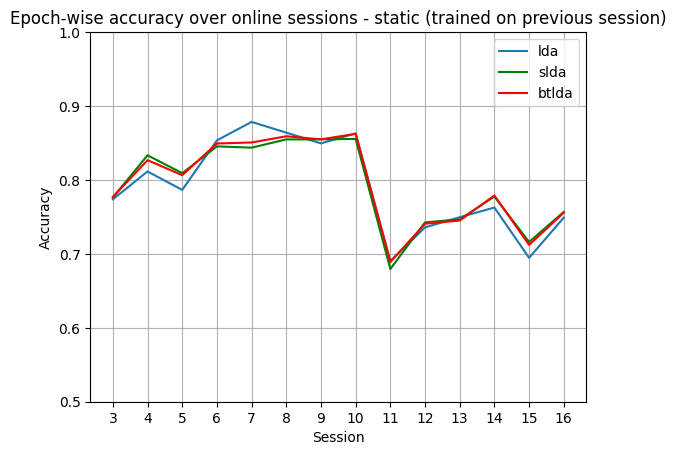

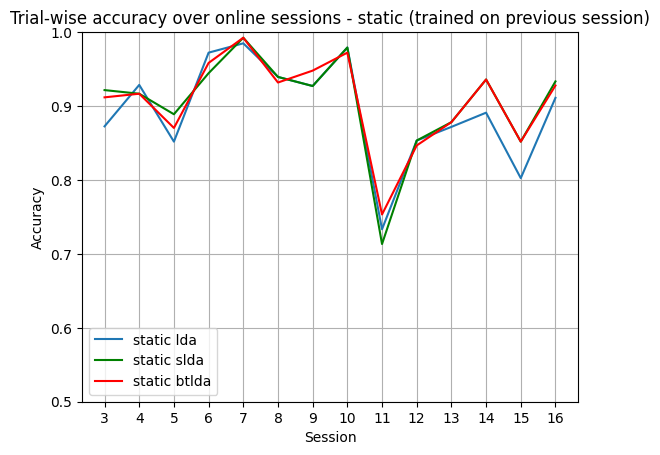

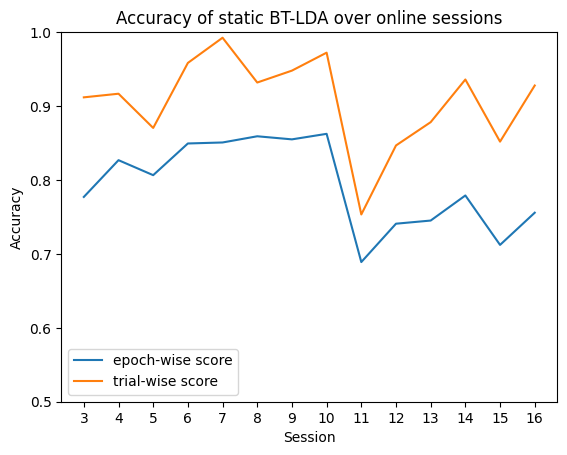

In [76]:
# Plot 1: Epoch-wise acc of static lda vs slda vs btlda

plt.figure()
plt.plot(ews_static_lda, label="lda")
plt.plot(ews_static_slda, label="slda", color="green")
plt.plot(ews_static_btlda, label="btlda", color="red")
plt.title("Epoch-wise accuracy over online sessions - static (trained on previous session)")
plt.xlabel("Session")
plt.ylabel("Accuracy")
plt.ylim((0.5,1))
plt.grid()
plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11,12,13],[3,4,5,6,7,8,9,10,11,12,13,14,15,16])
plt.legend()
plt.show()

# Plot 2: Trial-wise acc of static lda vs slda vs btlda

plt.figure()
plt.plot(tws_static_lda, label="static lda")
plt.plot(tws_static_slda, label="static slda", color="green")
plt.plot(tws_static_btlda, label="static btlda", color="red")
plt.title("Trial-wise accuracy over online sessions - static (trained on previous session)")
plt.xlabel("Session")
plt.ylabel("Accuracy")
plt.ylim((0.5,1))
plt.grid()
plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11,12,13],[3,4,5,6,7,8,9,10,11,12,13,14,15,16])
plt.legend()
plt.show()

# Plot 3: Epoch-wise acc vs trial-wise acc for static BT-LDA

plt.figure()
plt.plot(ews_static_btlda, label="epoch-wise score")
plt.plot(tws_static_btlda, label="trial-wise score")
plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11,12,13],[3,4,5,6,7,8,9,10,11,12,13,14,15,16])
#plt.xticks([0,1,2,3,4,5,6,7,8,9,10],[3,4,5,6,7,8,9,10,11,12,13])
plt.title("Accuracy of static BT-LDA over online sessions")
plt.xlabel("Session")
plt.ylabel("Accuracy")
plt.ylim((0.5,1))
plt.legend()
plt.show()

### Static (trained on previous session) vs Adaptive sliding window 

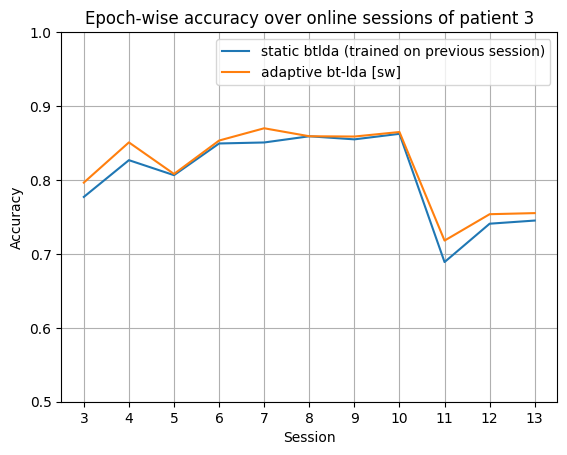

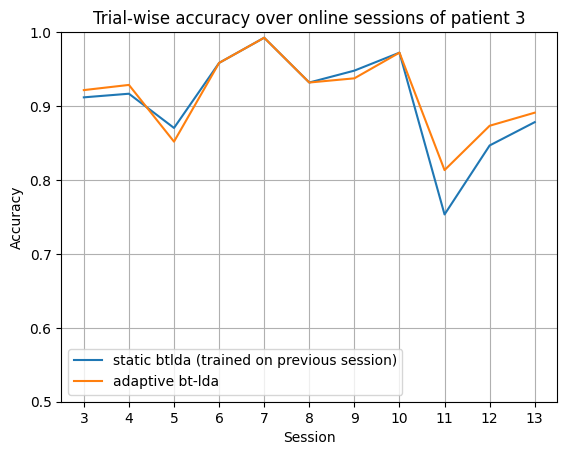

In [36]:
# Plot 1: Epoch-wise acc of static lda vs slda vs btlda

plt.figure()
#
#plt.plot(ews_static_lda, label="static lda (trained on previous session)", color="blue")
#plt.plot(ews_static_slda, label="static slda (trained on previous session)")
plt.plot(ews_static_btlda, label="static btlda (trained on previous session)")
# 
#plt.plot(ews_adaptive_sw_lda, label="adaptive lda [sw]")
#plt.plot(ews_adaptive_sw_slda, label="adaptive slda [sw]")
plt.plot(ews_adaptive_sw_btlda, label="adaptive bt-lda [sw]")
#

plt.title("Epoch-wise accuracy over online sessions of patient 3")
plt.xlabel("Session")
plt.ylabel("Accuracy")
plt.ylim((0.5,1))
plt.grid()
#plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14],[3,4,5,6,7,8,9,10,11,12,13,14,15,16,17])
plt.xticks([0,1,2,3,4,5,6,7,8,9,10],[3,4,5,6,7,8,9,10,11,12,13])
plt.legend()
plt.show()

# Plot 2: Trial-wise acc of static lda vs slda vs btlda

plt.figure()
#
#plt.plot(tws_static_lda, label="static lda (trained on previous session)", color="blue")
#plt.plot(tws_static_slda, label="static slda (trained on previous session)")
plt.plot(tws_static_btlda, label="static btlda (trained on previous session)")
#
#plt.plot(tws_adaptive_sw_lda, label="adaptive lda [sw]")
#plt.plot(tws_adaptive_sw_slda, label="adaptive slda [sw]")
plt.plot(tws_adaptive_sw_btlda, label="adaptive bt-lda")
#
plt.title("Trial-wise accuracy over online sessions of patient 3")
plt.xlabel("Session")
plt.ylabel("Accuracy")
plt.ylim((0.5,1))
plt.grid()
#plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14],[3,4,5,6,7,8,9,10,11,12,13,14,15,16,17])
plt.xticks([0,1,2,3,4,5,6,7,8,9,10],[3,4,5,6,7,8,9,10,11,12,13])
plt.legend()
plt.show()


### Static: LDA vs SLDA vs BT-LDA

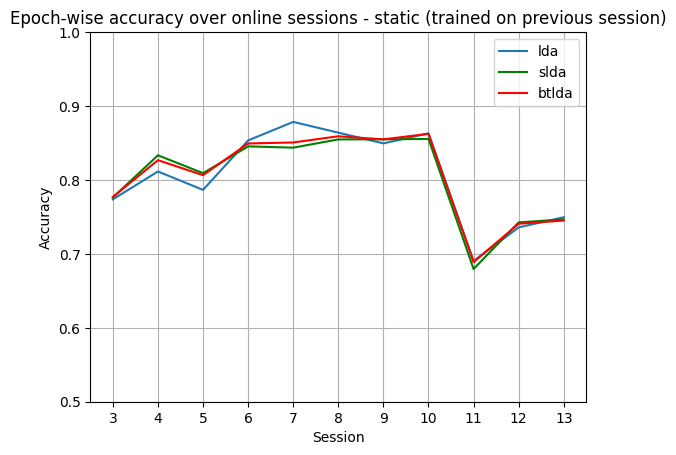

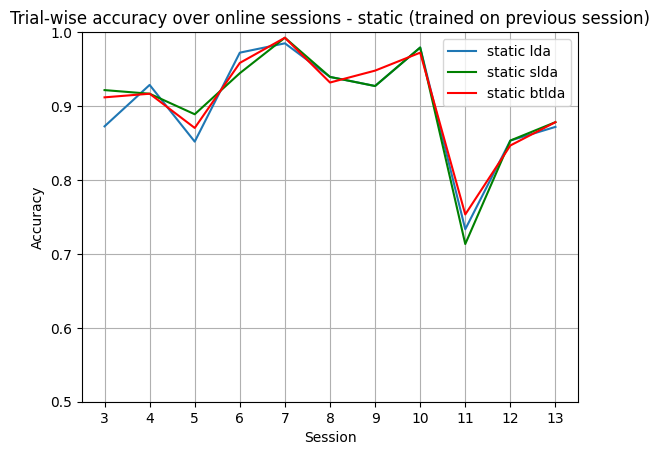

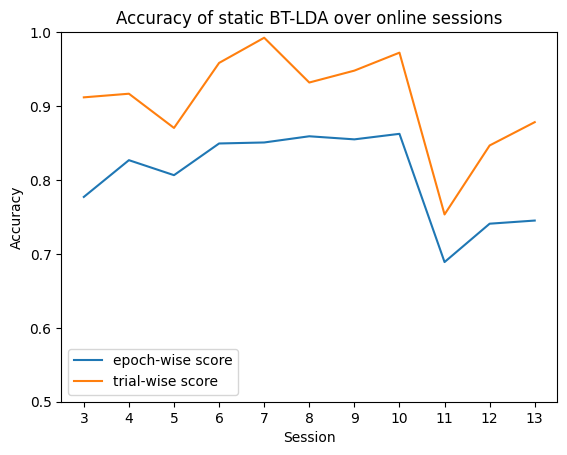

In [38]:
# Plot 1: Epoch-wise acc of static lda vs slda vs btlda

plt.figure()
plt.plot(ews_static_lda, label="lda")
plt.plot(ews_static_slda, label="slda", color="green")
plt.plot(ews_static_btlda, label="btlda", color="red")
plt.title("Epoch-wise accuracy over online sessions - static (trained on previous session)")
plt.xlabel("Session")
plt.ylabel("Accuracy")
plt.ylim((0.5,1))
plt.grid()
#plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14],[3,4,5,6,7,8,9,10,11,12,13,14,15,16,17])
plt.xticks([0,1,2,3,4,5,6,7,8,9,10],[3,4,5,6,7,8,9,10,11,12,13])
plt.legend()
plt.show()

# Plot 2: Trial-wise acc of static lda vs slda vs btlda

plt.figure()
plt.plot(tws_static_lda, label="static lda")
plt.plot(tws_static_slda, label="static slda", color="green")
plt.plot(tws_static_btlda, label="static btlda", color="red")
plt.title("Trial-wise accuracy over online sessions - static (trained on previous session)")
plt.xlabel("Session")
plt.ylabel("Accuracy")
plt.ylim((0.5,1))
plt.grid()
#plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14],[3,4,5,6,7,8,9,10,11,12,13,14,15,16,17])
plt.xticks([0,1,2,3,4,5,6,7,8,9,10],[3,4,5,6,7,8,9,10,11,12,13])
plt.legend()
plt.show()

# Plot 3: Epoch-wise acc vs trial-wise acc for static BT-LDA

plt.figure()
plt.plot(ews_static_btlda, label="epoch-wise score")
plt.plot(tws_static_btlda, label="trial-wise score")
#plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14],[3,4,5,6,7,8,9,10,11,12,13,14,15,16,17])
plt.xticks([0,1,2,3,4,5,6,7,8,9,10],[3,4,5,6,7,8,9,10,11,12,13])
plt.title("Accuracy of static BT-LDA over online sessions")
plt.xlabel("Session")
plt.ylabel("Accuracy")
plt.ylim((0.5,1))
plt.legend()
plt.show()

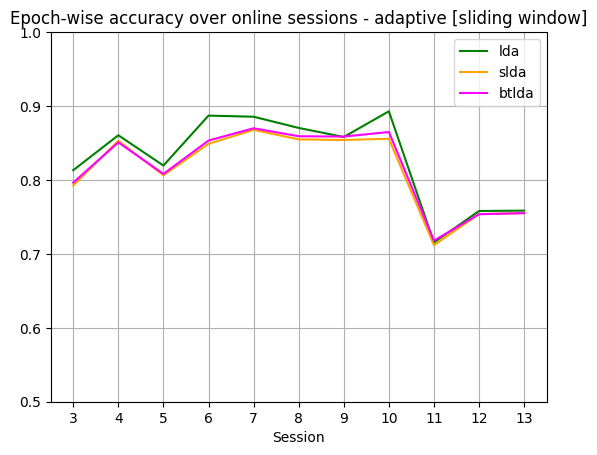

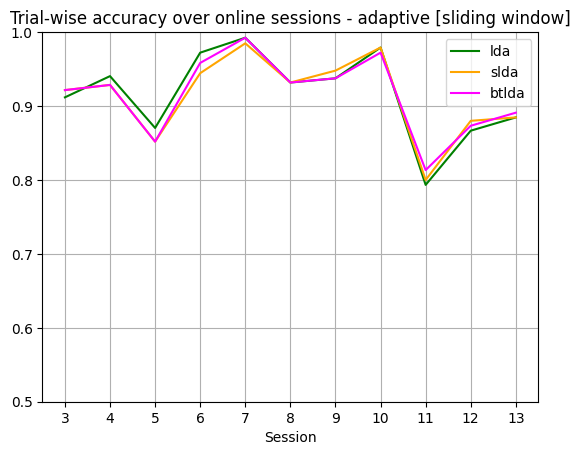

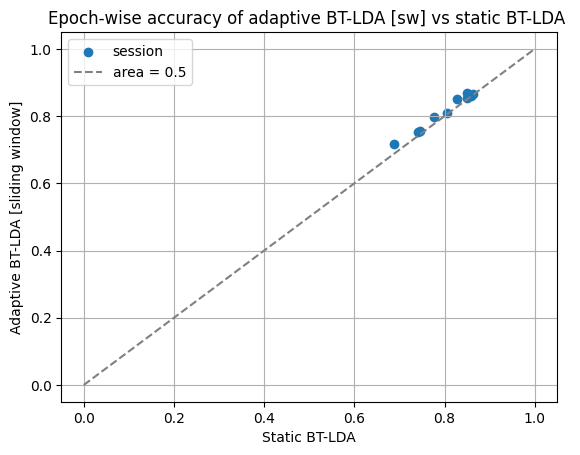

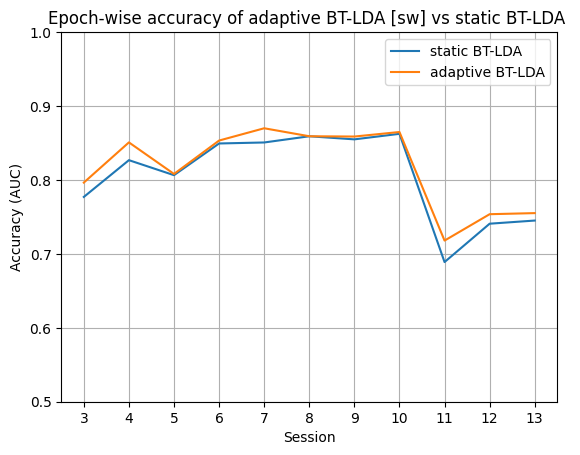

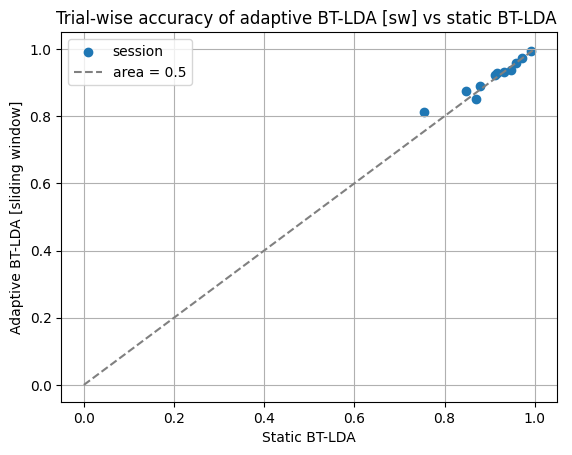

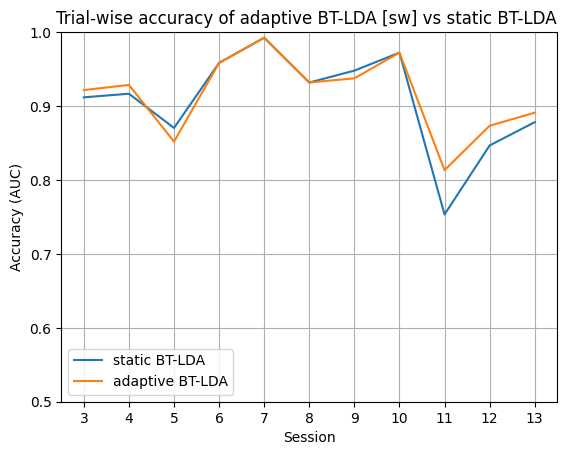

In [45]:
# Plot 1: Epoch-wise scores lda vs slda vs btlda

plt.figure()
plt.plot(ews_adaptive_sw_lda, label="lda", color = "green")
plt.plot(ews_adaptive_sw_slda, label="slda", color="orange")
plt.plot(ews_adaptive_sw_btlda, label="btlda", color="magenta")
plt.title("Epoch-wise accuracy over online sessions - adaptive [sliding window]")
plt.xlabel("Session")
plt.grid()
plt.ylim((0.5,1))
plt.xticks([0,1,2,3,4,5,6,7,8,9,10],[3,4,5,6,7,8,9,10,11,12,13])
#plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14],[3,4,5,6,7,8,9,10,11,12,13,14,15,16,17])
plt.legend()
plt.show()

# Plot 2: Trial-wise scores lda vs slda vs btlda

plt.figure()
plt.plot(tws_adaptive_sw_lda, label="lda",color="green")
plt.plot(tws_adaptive_sw_slda, label="slda", color="orange")
plt.plot(tws_adaptive_sw_btlda, label="btlda", color="magenta")
plt.title("Trial-wise accuracy over online sessions - adaptive [sliding window]")
plt.xlabel("Session")
plt.grid()
plt.ylim((0.5,1))
plt.xticks([0,1,2,3,4,5,6,7,8,9,10],[3,4,5,6,7,8,9,10,11,12,13])
#plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14],[3,4,5,6,7,8,9,10,11,12,13,14,15,16,17])
plt.legend()
plt.show()

# Plot 3: Epoch-wise score of static BT-LDA vs adaptive BT-LDA [sliding window]

plt.figure()
plt.scatter(ews_static_btlda, ews_adaptive_sw_btlda, label="session")
plt.plot([0, 1],[0,1], '--', color='gray', label="area = 0.5")
plt.title("Epoch-wise accuracy of adaptive BT-LDA [sw] vs static BT-LDA ")
plt.ylabel("Adaptive BT-LDA [sliding window]")
plt.xlabel("Static BT-LDA")
#plt.xticks([0,1,2,3,4,5,6,7,8,9,10],[3,4,5,6,7,8,9,10,11,12,13])
plt.grid()
plt.legend()
plt.show()

# Plot 4: Epoch-wise score of static BT-LDA vs adaptive BT-LDA [sliding window]

plt.figure()
plt.plot(ews_static_btlda, label="static BT-LDA")
plt.plot(ews_adaptive_sw_btlda, label="adaptive BT-LDA")
plt.title("Epoch-wise accuracy of adaptive BT-LDA [sw] vs static BT-LDA ")
plt.ylabel("Accuracy (AUC)")
plt.xlabel("Session")
plt.grid()
plt.ylim((0.5,1))
plt.xticks([0,1,2,3,4,5,6,7,8,9,10],[3,4,5,6,7,8,9,10,11,12,13])
#plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14],[3,4,5,6,7,8,9,10,11,12,13,14,15,16,17])
plt.legend()
plt.show()

# Plot 5: Trial-wise score of static BT-LDA vs adaptive BT-LDA [sliding window]

plt.figure()
plt.scatter(tws_static_btlda, tws_adaptive_sw_btlda, label="session")
plt.plot([0, 1],[0,1], '--', color='gray', label="area = 0.5")
plt.title("Trial-wise accuracy of adaptive BT-LDA [sw] vs static BT-LDA ")
plt.ylabel("Adaptive BT-LDA [sliding window]")
plt.xlabel("Static BT-LDA")
plt.grid()
#plt.xticks([0,1,2,3,4,5,6,7,8,9,10],[3,4,5,6,7,8,9,10,11,12,13])
plt.legend()
plt.show()

# Plot 6: Trial-wise score of static BT-LDA vs adaptive BT-LDA [sliding window]

plt.figure()
plt.plot(tws_static_btlda, label="static BT-LDA")
plt.plot(tws_adaptive_sw_btlda, label="adaptive BT-LDA")
plt.title("Trial-wise accuracy of adaptive BT-LDA [sw] vs static BT-LDA ")
plt.ylabel("Accuracy (AUC)")
plt.xlabel("Session")
plt.grid()
plt.ylim((0.5,1))
plt.xticks([0,1,2,3,4,5,6,7,8,9,10],[3,4,5,6,7,8,9,10,11,12,13])
#plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14],[3,4,5,6,7,8,9,10,11,12,13,14,15,16,17])
plt.legend()
plt.show()

#### Trial-wise vs Epoch-wise for all three classifiers (LDA - sLDA - BTLDA)

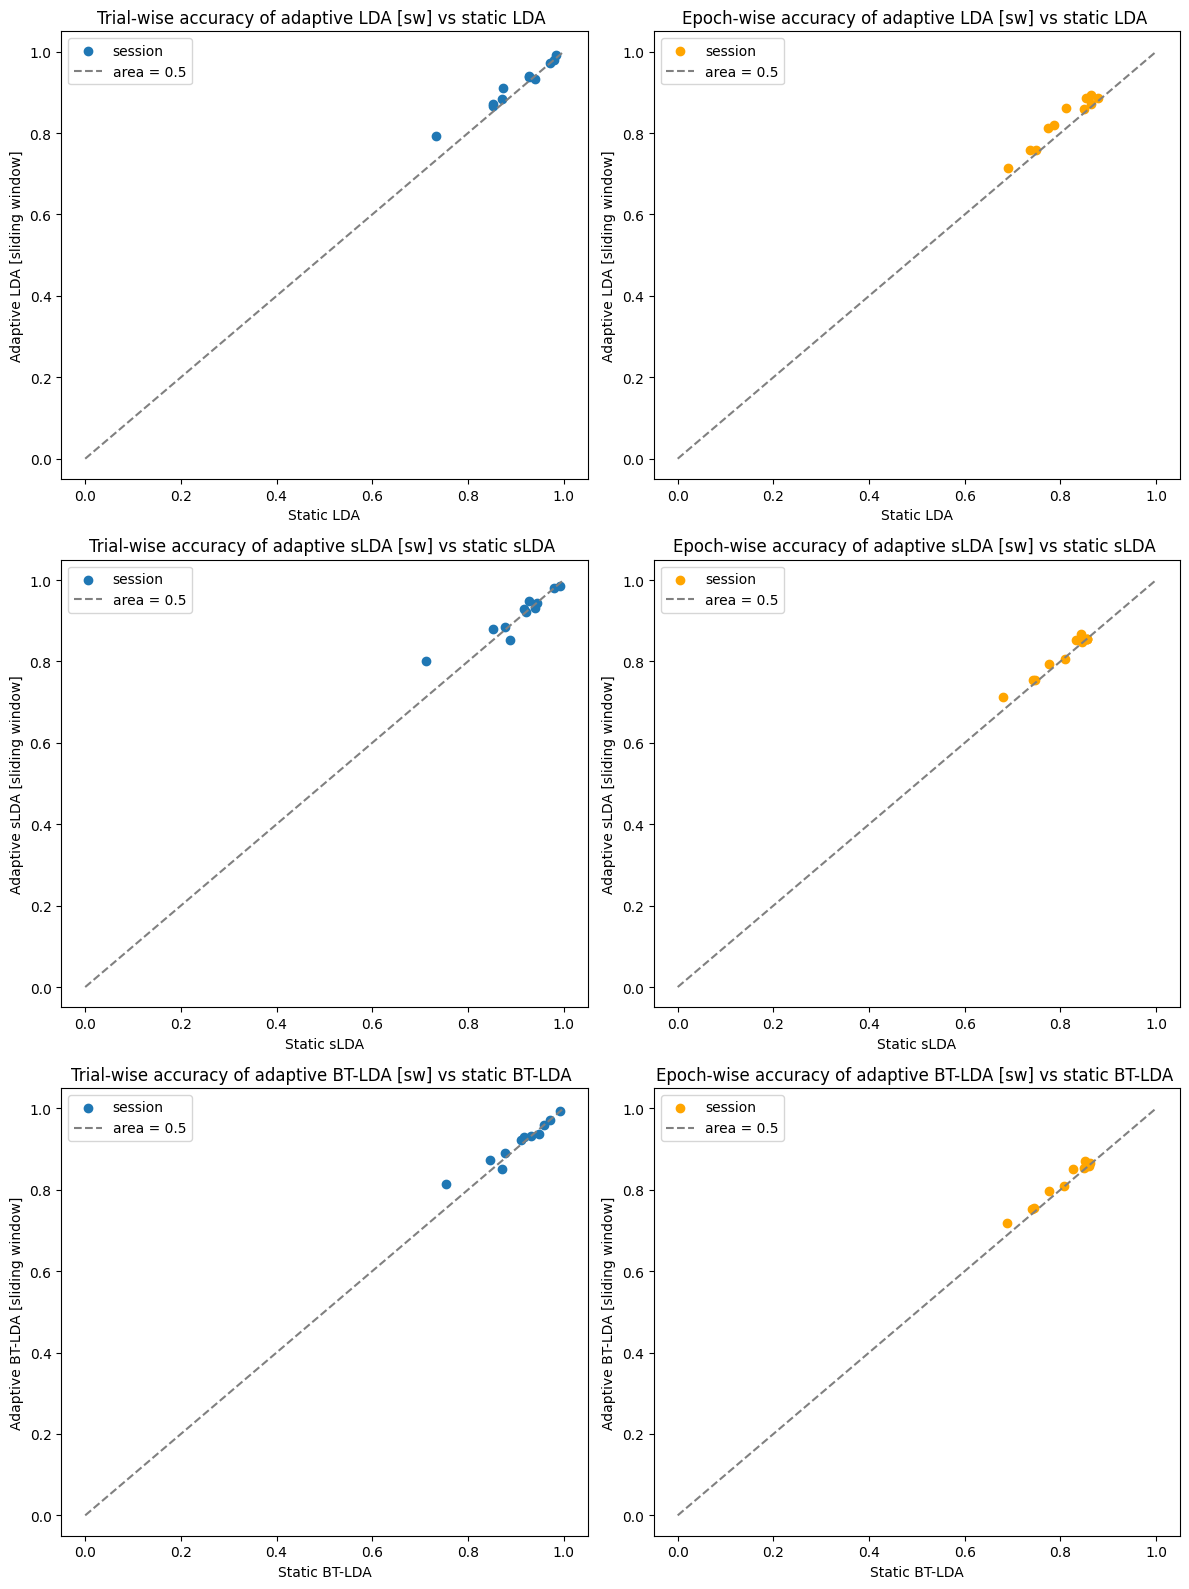

In [46]:
fig, axes = plt.subplots(3,2, figsize=(12,16))

axes[0,0].scatter(tws_static_lda, tws_adaptive_sw_lda, label="session")
axes[0,0].plot([0, 1],[0,1], '--', color='gray', label="area = 0.5")
axes[0,0].set_title("Trial-wise accuracy of adaptive LDA [sw] vs static LDA ")
axes[0,0].set_ylabel("Adaptive LDA [sliding window]")
axes[0,0].set_xlabel("Static LDA")
axes[0,0].legend()

axes[0,1].scatter(ews_static_lda, ews_adaptive_sw_lda, label="session", color="orange")
axes[0,1].plot([0, 1],[0,1], '--', color='gray', label="area = 0.5")
axes[0,1].set_title("Epoch-wise accuracy of adaptive LDA [sw] vs static LDA ")
axes[0,1].set_ylabel("Adaptive LDA [sliding window]")
axes[0,1].set_xlabel("Static LDA")
axes[0,1].legend()

axes[1,0].scatter(tws_static_slda, tws_adaptive_sw_slda, label="session")
axes[1,0].plot([0, 1],[0,1], '--', color='gray', label="area = 0.5")
axes[1,0].set_title("Trial-wise accuracy of adaptive sLDA [sw] vs static sLDA ")
axes[1,0].set_ylabel("Adaptive sLDA [sliding window]")
axes[1,0].set_xlabel("Static sLDA")
axes[1,0].legend()

axes[1,1].scatter(ews_static_slda, ews_adaptive_sw_slda, label="session", color="orange")
axes[1,1].plot([0, 1],[0,1], '--', color='gray', label="area = 0.5")
axes[1,1].set_title("Epoch-wise accuracy of adaptive sLDA [sw] vs static sLDA ")
axes[1,1].set_ylabel("Adaptive sLDA [sliding window]")
axes[1,1].set_xlabel("Static sLDA")
axes[1,1].legend()

axes[2,0].scatter(tws_static_btlda, tws_adaptive_sw_btlda, label="session")
axes[2,0].plot([0, 1],[0,1], '--', color='gray', label="area = 0.5")
axes[2,0].set_title("Trial-wise accuracy of adaptive BT-LDA [sw] vs static BT-LDA ")
axes[2,0].set_ylabel("Adaptive BT-LDA [sliding window]")
axes[2,0].set_xlabel("Static BT-LDA")
axes[2,0].legend()

axes[2,1].scatter(ews_static_btlda, ews_adaptive_sw_btlda, label="session", color="orange")
axes[2,1].plot([0, 1],[0,1], '--', color='gray', label="area = 0.5")
axes[2,1].set_title("Epoch-wise accuracy of adaptive BT-LDA [sw] vs static BT-LDA ")
axes[2,1].set_ylabel("Adaptive BT-LDA [sliding window]")
axes[2,1].set_xlabel("Static BT-LDA")
axes[2,1].legend()

plt.tight_layout()
plt.show()

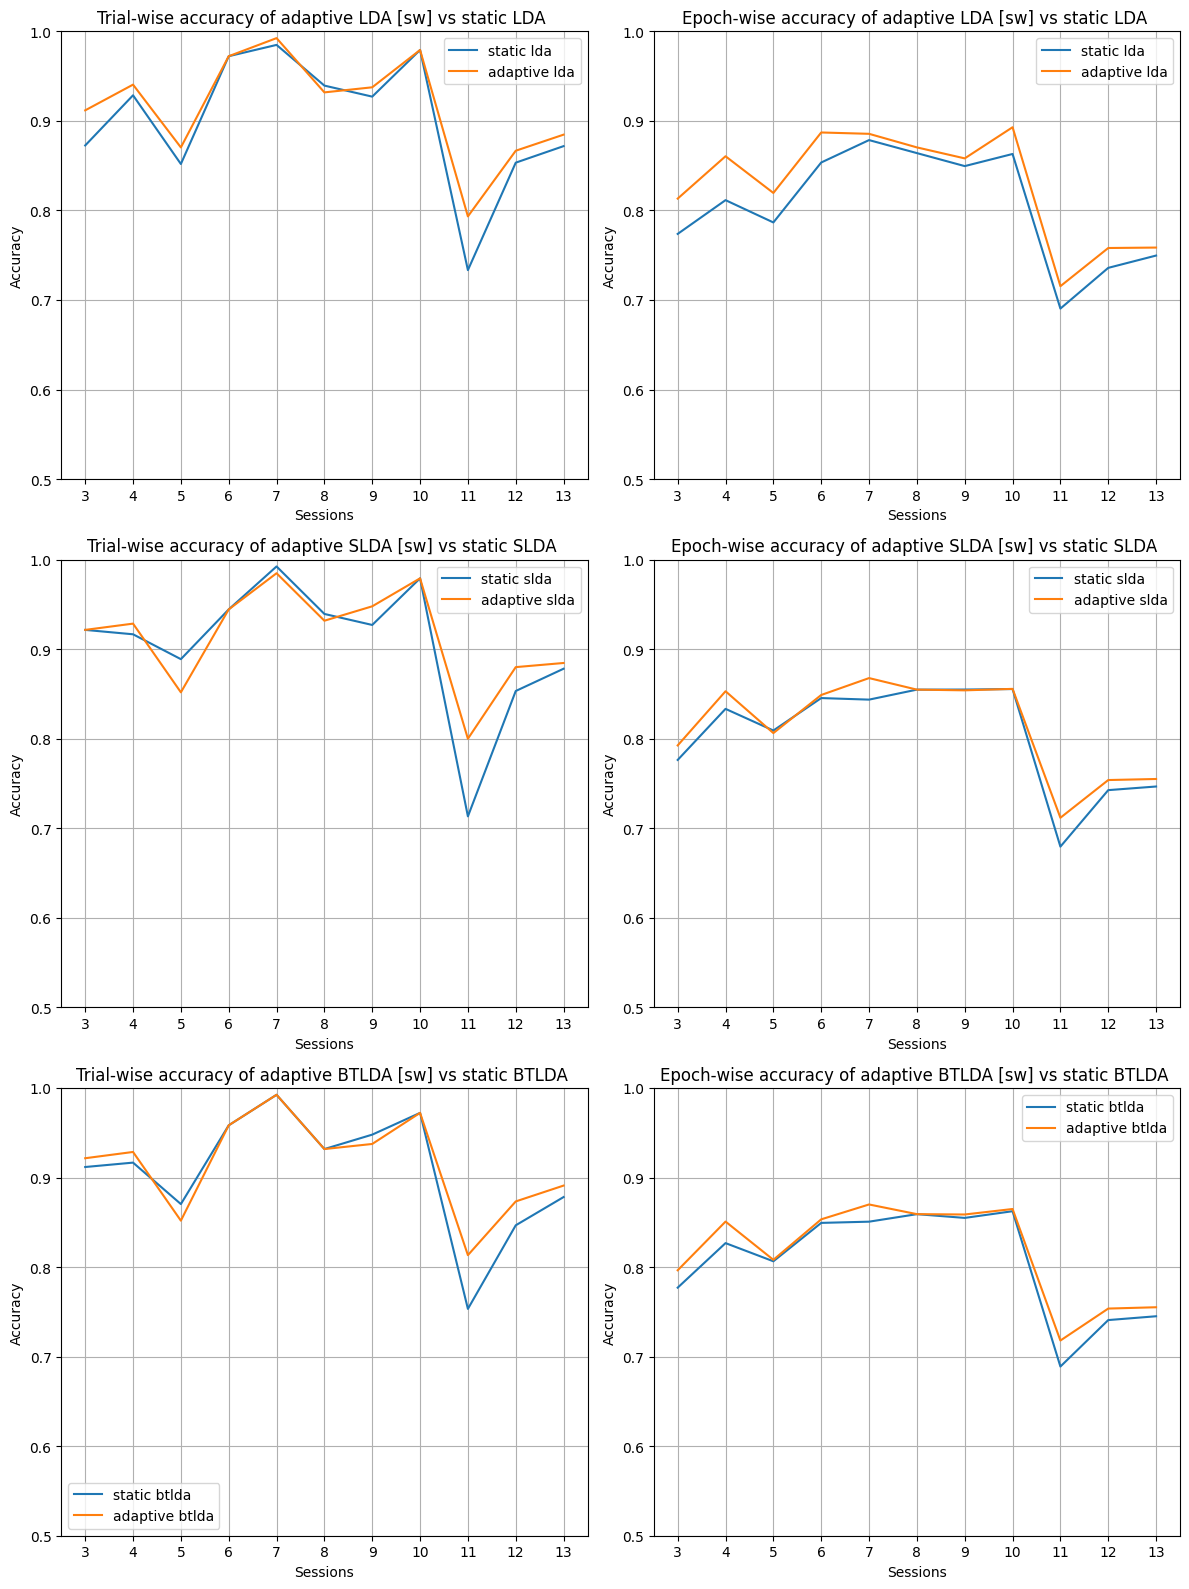

In [55]:
fig, axes = plt.subplots(3,2, figsize=(12,16))

axes[0,0].plot(tws_static_lda, label="static lda")
axes[0,0].plot(tws_adaptive_sw_lda, label="adaptive lda")
axes[0,0].set_title("Trial-wise accuracy of adaptive LDA [sw] vs static LDA ")
axes[0,0].set_ylabel("Accuracy")
axes[0,0].set_xlabel("Sessions")
axes[0,0].legend()
axes[0,0].grid()
axes[0,0].set_ylim((0.5,1))
axes[0,0].set_xticks([0,1,2,3,4,5,6,7,8,9,10],[3,4,5,6,7,8,9,10,11,12,13])

axes[0,1].plot(ews_static_lda, label="static lda")
axes[0,1].plot(ews_adaptive_sw_lda, label="adaptive lda")
axes[0,1].set_title("Epoch-wise accuracy of adaptive LDA [sw] vs static LDA ")
axes[0,1].set_ylabel("Accuracy")
axes[0,1].set_xlabel("Sessions")
axes[0,1].legend()
axes[0,1].grid()
axes[0,1].set_ylim((0.5,1))
axes[0,1].set_xticks([0,1,2,3,4,5,6,7,8,9,10],[3,4,5,6,7,8,9,10,11,12,13])

axes[1,0].plot(tws_static_slda, label="static slda")
axes[1,0].plot(tws_adaptive_sw_slda, label="adaptive slda")
axes[1,0].set_title("Trial-wise accuracy of adaptive SLDA [sw] vs static SLDA ")
axes[1,0].set_ylabel("Accuracy")
axes[1,0].set_xlabel("Sessions")
axes[1,0].legend()
axes[1,0].grid()
axes[1,0].set_ylim((0.5,1))
axes[1,0].set_xticks([0,1,2,3,4,5,6,7,8,9,10],[3,4,5,6,7,8,9,10,11,12,13])

axes[1,1].plot(ews_static_slda, label="static slda")
axes[1,1].plot(ews_adaptive_sw_slda, label="adaptive slda")
axes[1,1].set_title("Epoch-wise accuracy of adaptive SLDA [sw] vs static SLDA ")
axes[1,1].set_ylabel("Accuracy")
axes[1,1].set_xlabel("Sessions")
axes[1,1].legend()
axes[1,1].grid()
axes[1,1].set_ylim((0.5,1))
axes[1,1].set_xticks([0,1,2,3,4,5,6,7,8,9,10],[3,4,5,6,7,8,9,10,11,12,13])

axes[2,0].plot(tws_static_btlda, label="static btlda")
axes[2,0].plot(tws_adaptive_sw_btlda, label="adaptive btlda")
axes[2,0].set_title("Trial-wise accuracy of adaptive BTLDA [sw] vs static BTLDA ")
axes[2,0].set_ylabel("Accuracy")
axes[2,0].set_xlabel("Sessions")
axes[2,0].legend()
axes[2,0].grid()
axes[2,0].set_ylim((0.5,1))
axes[2,0].set_xticks([0,1,2,3,4,5,6,7,8,9,10],[3,4,5,6,7,8,9,10,11,12,13])

axes[2,1].plot(ews_static_btlda, label="static btlda")
axes[2,1].plot(ews_adaptive_sw_btlda, label="adaptive btlda")
axes[2,1].set_title("Epoch-wise accuracy of adaptive BTLDA [sw] vs static BTLDA ")
axes[2,1].set_ylabel("Accuracy")
axes[2,1].set_xlabel("Sessions")
axes[2,1].legend()
axes[2,1].grid()
axes[2,1].set_ylim((0.5,1))
axes[2,1].set_xticks([0,1,2,3,4,5,6,7,8,9,10],[3,4,5,6,7,8,9,10,11,12,13])

plt.tight_layout()
plt.show()